               Id         groupId         matchId  assists  boosts  \
0  7f96b2f878858a  4d4b580de459be  a10357fd1a4a91        0       0   
1  eef90569b9d03c  684d5656442f9e  aeb375fc57110c        0       0   
2  1eaf90ac73de72  6a4a42c3245a74  110163d8bb94ae        1       0   
3  4616d365dd2853  a930a9c79cd721  f1f1f4ef412d7e        0       0   
4  315c96c26c9aac  de04010b3458dd  6dc8ff871e21e6        0       0   

  damageDealt  DBNOs  headshotKills  heals  killPlace  ...  revives  \
0         0.0      0              0      0         60  ...        0   
1       91.47      0              0      0         57  ...        0   
2        68.0      0              0      0         47  ...        0   
3        32.9      0              0      0         75  ...        0   
4       100.0      0              0      0         45  ...        0   

   rideDistance  roadKills  swimDistance  teamKills vehicleDestroys  \
0        0.0000          0          0.00          0               0   
1        0

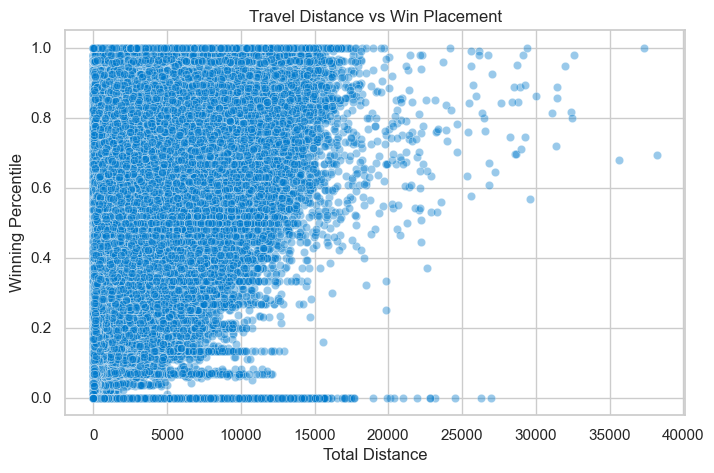

C:\Users\Rayhab\AppData\Local\Temp\ipykernel_5424\3226811669.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="matchType", y="kills", data=df, palette="Set2")


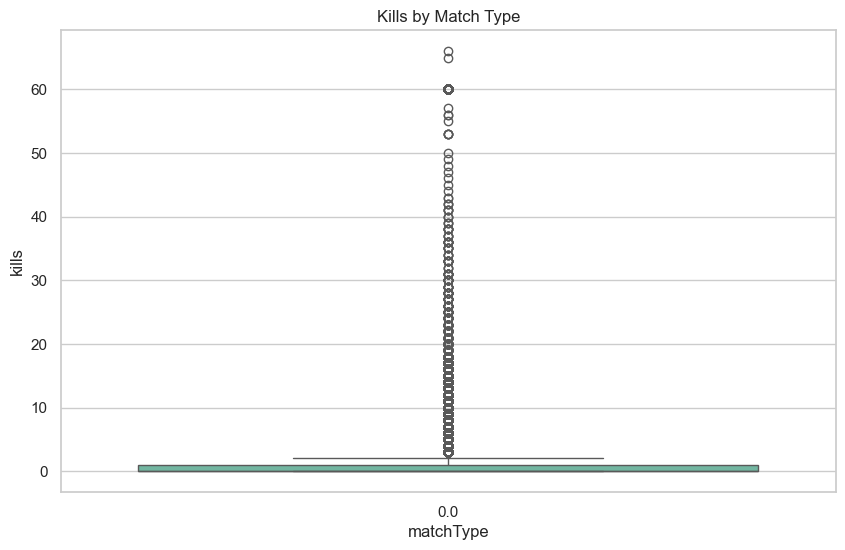

C:\Users\Rayhab\AppData\Local\Temp\ipykernel_5424\3226811669.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="playStyle", y="winPlacePerc", data=df, errorbar=None, palette=["#2ecc71","#e74c3c"])


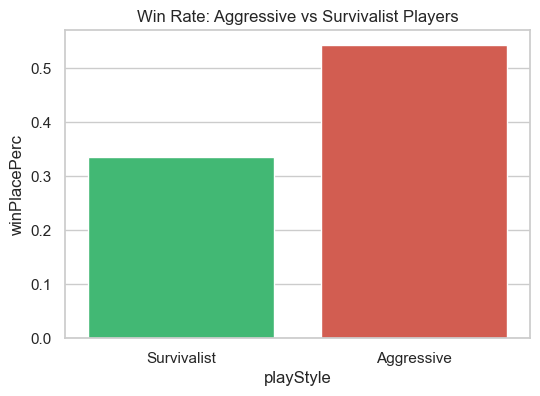

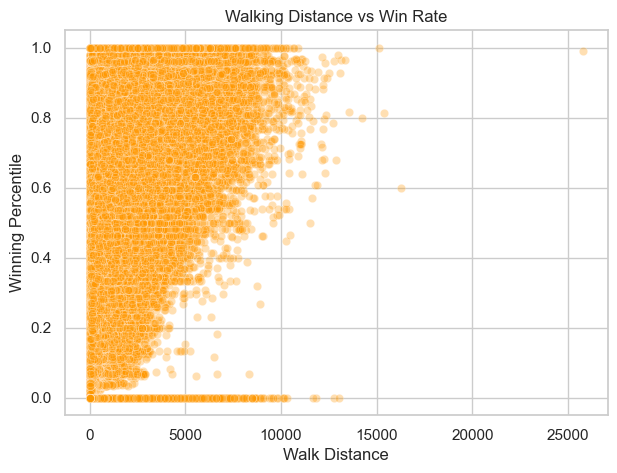

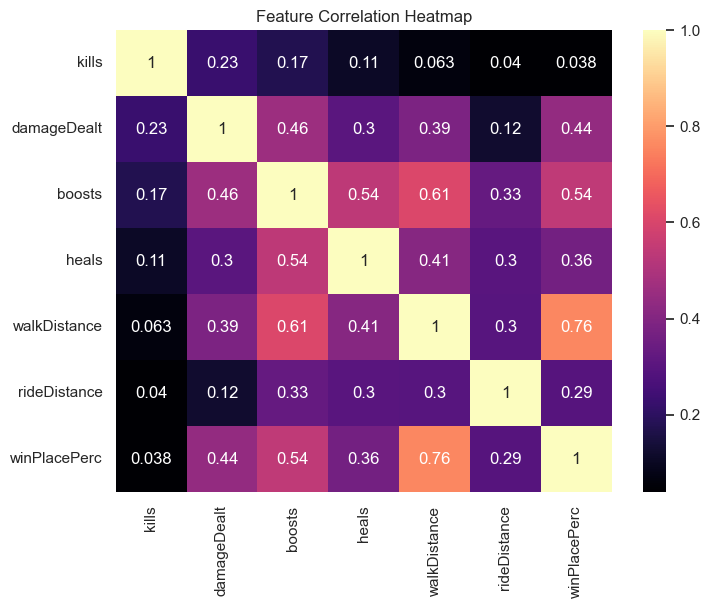


Insight:
Players who cover more walking distance 
tend to perform better.



In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("pubg.csv")
print(df.head())
# Data Cleaning 
print("Shape =", df.shape)
print("\nMissing values before cleaning =\n", df.isnull().sum())

def safe_convert(x):
    try:
        return float(x)
    except:
        return np.nan  # or 0 ,depends

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].apply(safe_convert)

# any value less than 0 will be replaed with zero
df = df.clip(lower=0)

print("After cleaning:", df.shape)

df.fillna(0, inplace=True)
df.drop_duplicates(inplace=True)

# Feature Engineering 
df["totalDistance"] = df["walkDistance"] + df["rideDistance"] + df["swimDistance"]
df["headshotRate"] = np.where(df["kills"] > 0, df["headshotKills"] / df["kills"], 0)
df["itemsUsed"] = df["heals"] + df["boosts"]

# EDA 
sns.set(style="whitegrid")

# Travel distance vs win rate
plt.figure(figsize=(8,5))
sns.scatterplot(x="totalDistance", y="winPlacePerc", data=df, alpha=0.4, color="#007acc")
plt.title("Travel Distance vs Win Placement")
plt.xlabel("Total Distance")
plt.ylabel("Winning Percentile")
plt.show()

# Kills by match type
plt.figure(figsize=(10,6))
sns.boxplot(x="matchType", y="kills", data=df, palette="Set2")
plt.title("Kills by Match Type")
plt.show()

# Aggressive vs Survivalist players
df["playStyle"] = np.where(df["kills"] > df["kills"].median(), "Aggressive", "Survivalist")

plt.figure(figsize=(6,4))
sns.barplot(x="playStyle", y="winPlacePerc", data=df, errorbar=None, palette=["#2ecc71","#e74c3c"])
plt.title("Win Rate: Aggressive vs Survivalist Players")
plt.show()

# Walking distance vs Win rate
plt.figure(figsize=(7,5))
sns.scatterplot(x="walkDistance", y="winPlacePerc", data=df, alpha=0.3, color="#ff9800")
plt.title("Walking Distance vs Win Rate")
plt.xlabel("Walk Distance")
plt.ylabel("Winning Percentile")
plt.show()

# Correlation heatmap
corr_features = ["kills", "damageDealt", "boosts", "heals", "walkDistance", "rideDistance", "winPlacePerc"]
plt.figure(figsize=(8,6))
sns.heatmap(df[corr_features].corr(), annot=True, cmap="magma")
plt.title("Feature Correlation Heatmap")
plt.show()
print("""
Insight:
Players who cover more walking distance 
tend to perform better.
""")
